# Neurons and neural nets

A **neuron** is the fundamental computational unit of a neural network. Despite the biological nomenclature, it is functionally a mathematical operation. A single neuron executes three primary steps:

1. **Linear Combination**: It accepts a vector of input features and calculates a weighted sum, typically including a bias term.
2. **Activation**: It applies a non-linear **activation function** to the result of the linear combination. An example is a sigmoid or a ReLU.
3. **Optimization**: The weights of the linear combination and bias are **learnable parameters**, adjusted during training to minimize error in the final output.

For example, suppose a neuron accepts three features ($\phi_1, \phi_2, \phi_3$), and is using a sigmoid activation function ($\sigma(x) = \frac{1}{1+e^{-x}}$). It currently has the learned parameters $\begin{bmatrix}
w_1 \\
w_2 \\
w_3 \\
b
\end{bmatrix}$. The math within the neuron would be:

$$
\sigma\left(\begin{bmatrix} \phi_1 & \phi_2 & \phi_3 & 1 \end{bmatrix}
\begin{bmatrix}
w_1 \\
w_2 \\
w_3 \\
b
\end{bmatrix}\right)
$$

which is a scalar.

A single neuron is rarely the optimal choice for a predictive model. In isolation, its representative power is limited. Most tasks suitable for a single neuron can be performed more efficiently by standard **linear models** (such as linear or logistic regression), which often benefit from faster convergence and lower computational overhead.

The utility of neural networks emerges from **layering**. When the output of one neuron serves as the input to a subsequent neuron, the first neuron acts as an automated **feature extractor**.

* **Hierarchical Representation**: Each successive layer processes the "features" identified by the previous layer.
* **Joint Optimization**: By training all neurons across all layers simultaneously, the network learns to transform raw data into increasingly complex features, which are useful for the final task.
* **Final Output**: The ultimate layer performs a linear combination of these learned features to produce the final prediction.

## Demo and explanation

To begin the implementation in PyTorch, we generate a synthetic dataset for a binary classification task. We will create two distinct clusters of points in a 2D plane ($X \in \mathbb{R}^2$), where each cluster represents a specific class ($t \in \{0, 1\}$).

In [1]:
import numpy as np

# Set seed for reproducibility
np.random.seed(42)

# Generate 100 samples for Class 0 (centered around [2, 2])
# X0 follows N(mu=[2, 2], sigma=I)
class0_x = np.random.randn(100, 2) + np.array([2.0, 2.0])
class0_y = np.zeros((100, 1))

# Generate 100 samples for Class 1 (centered around [-2, -2])
# X1 follows N(mu=[-2, -2], sigma=I)
class1_x = np.random.randn(100, 2) + np.array([-2.0, -2.0])
class1_y = np.ones((100, 1))

# Concatenate into final training arrays
X = np.concatenate((class0_x, class1_x), axis=0)
y = np.concatenate((class0_y, class1_y), axis=0)

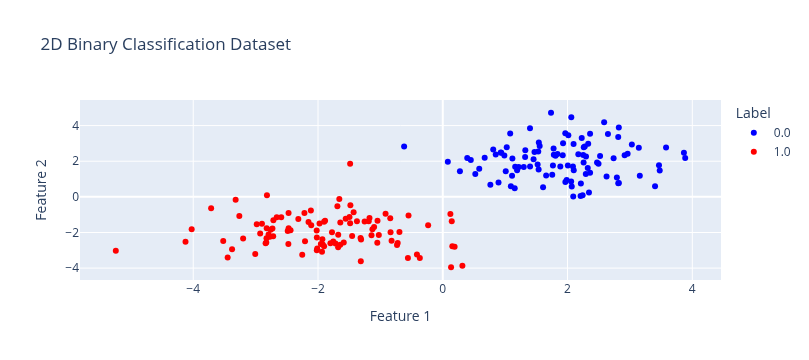

In [2]:
import plotly.express as px

# Create interactive scatter plot using NumPy arrays
fig = px.scatter(
    x=X[:, 0], 
    y=X[:, 1], 
    color=y.flatten().astype(str),
    title="2D Binary Classification Dataset",
    labels={'x': 'Feature 1', 'y': 'Feature 2', 'color': 'Label'},
    color_discrete_map={'0.0': 'blue', '1.0': 'red'}
)

fig.show()



We now define a neuron using Pytorch. We create a class called `MyNeuron`, which defines what happens to a single datapoint in this network of one neuron. This neuron takes in 2 values (our $x$ and $y$), and outputs a single value (that's where the 2 and 1 come from in the `nn.Linear()` line). It then feeds the result into a Sigmoid, which will output some value between 0 and 1.

`__init__` defines what each of the layers are, and forward() defines what calculations take place within the network.


In [3]:
import torch
import torch.nn as nn

class MyNeuron(nn.Module):
    def __init__(self):
        super(MyNeuron, self).__init__()
        # Define a linear layer with 2 inputs and 1 output
        self.linear = nn.Linear(2, 1)
        # Define the sigmoid activation function
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # Calculate the linear combination
        linear_output = self.linear(x)
        # Apply the non-linear activation
        output = self.sigmoid(linear_output)
        return output

# Instantiate the neuron
model = MyNeuron()

We now define the rest of the training process, where we will use SGD to minimize
$$ \min_{w_1,w_2,b} \frac{1}{N}\sum_i \left(\sigma(x_i\cdot w_1+y_i\cdot w_2+b)-t_i\right)^2, $$

where $x_i$ and $y_i$ are the features fed in for data point $i$, $t_i$ is the target value (0 or 1), $\sigma$ is the logistic sigmoid function, and $N$ is the number of training points in the training set. (This is a pretty nonstandard loss function for classification, but we'll get to that later).


In [4]:
import torch.optim as optim

# 1. Prepare Data (Convert NumPy arrays to Tensors)
X_tensor = torch.from_numpy(X).float()
y_tensor = torch.from_numpy(y).float()

# 2. Initialize Model, Criterion, and Optimizer
model = MyNeuron()
criterion = nn.MSELoss() # Implements the mean squared error formula
optimizer = optim.SGD(model.parameters(), lr=0.1)

# 3. Training Loop
epochs = 1000
for epoch in range(epochs):
    # Forward pass: Compute predicted y by passing x to the model
    y_pred = model(X_tensor)

    # Compute loss
    loss = criterion(y_pred, y_tensor)

    # Zero gradients, perform a backward pass, and update the weights.
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 100 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

Epoch [100/1000], Loss: 0.0106
Epoch [200/1000], Loss: 0.0068
Epoch [300/1000], Loss: 0.0053
Epoch [400/1000], Loss: 0.0045
Epoch [500/1000], Loss: 0.0040
Epoch [600/1000], Loss: 0.0036
Epoch [700/1000], Loss: 0.0033
Epoch [800/1000], Loss: 0.0031
Epoch [900/1000], Loss: 0.0029
Epoch [1000/1000], Loss: 0.0028


### Step-by-step breakdown of training

**Data Preparation (Tensor Conversion)**

Before PyTorch can process the data, it must be converted from NumPy arrays into **PyTorch Tensors**.

* **`torch.from_numpy(X)`**: This converts the raw data into a format PyTorch understands (PyTorch Tensors).
* **`.float()`**: This is a mandatory step because PyTorch’s `nn.Linear` layers require data to be in `float32` format. If you leave them as default NumPy doubles (`float64`), the code will throw an error.

**Setup: Model, Loss, and Optimizer**

* **`model = MyNeuron()`**: Instantiates the class to create the actual neuron.
* **`criterion = nn.MSELoss()`**: This is the **Loss Function**. Mean Squared Error!
* **`optimizer = optim.SGD(...)`**: This is the **Stochastic Gradient Descent** algorithm. We pass it `model.parameters()` so it knows what the parameters of the optimization problem are. `lr` is the learning rate or stepsize for SGD.

**The Training Loop (Epochs)**

The `for epoch in range(epochs):` line tells the computer to look at the entire dataset 1,000 times.

**Inside the Loop: The Learning Steps**

Every epoch follows the same five-step sequence:

1. **Forward Pass (`y_pred = model(X_tensor)`)**: The data is fed into the neuron. It calculates the linear combination ($wx+b$), applies the Sigmoid function, and outputs a prediction.
2. **Compute Loss (`loss = criterion(...)`)**: The prediction is compared to the actual target ($y$). The result is a single number representing the model's total error for that pass.
3. **Zero Gradients (`optimizer.zero_grad()`)**: This is a crucial "housekeeping" step. PyTorch accumulates (adds up) gradients by default. You must clear out the gradients from the *previous* step so you don't accidentally add the new corrections to the old ones.
4. **Backward Pass (`loss.backward()`)**: This is **Backpropagation**. PyTorch travels backward through your model's math to calculate the gradient of the loss function with respect to each parameter.
5. **Optimizer Step (`optimizer.step()`)**: This is a single gradient descent step, given the gradients calculated in the backward pass.

**Monitoring**

* **`print(...)`**: Every 100 epochs, the code prints the current loss. You want to see this number consistently decreasing; if it stays flat or increases, your learning rate (`lr`) might be set incorrectly.

To visualize the predictions, we must pass the input data through the trained neuron to obtain the predicted probabilities. We can then plot these probabilities against the original coordinates using Plotly.

First, we switch the model to evaluation mode and perform a forward pass without calculating gradients. We can visualize the model's performance by coloring the points by the neuron's output to see how confident the neuron is about each region of the 2D space. Points with a predicted value near $1.0$ appear dark red, while points near $0.0$ appear dark blue. The transition zone (where the color is muted) represents the decision boundary where the neuron is uncertain ($\hat{y} \approx 0.5$).

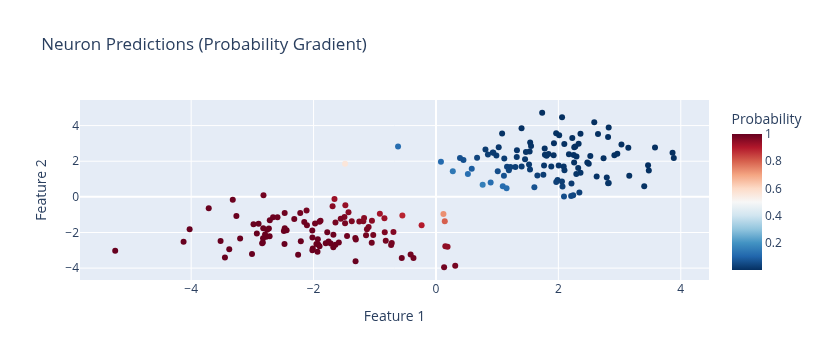

In [5]:
# Set the model to evaluation mode
model.eval()

with torch.no_grad():
    # Get probability outputs from the neuron
    predictions = model(X_tensor).numpy()

# Flatten predictions for plotting
predictions = predictions.flatten()

# Create interactive scatter plot
fig = px.scatter(
    x=X[:, 0], 
    y=X[:, 1], 
    color=predictions,
    title="Neuron Predictions (Probability Gradient)",
    labels={'x': 'Feature 1', 'y': 'Feature 2', 'color': 'Predicted Prob'},
    color_continuous_scale='RdBu_r' # Red for Class 1, Blue for Class 0
)

# Add a midpoint indicator at 0.5 (the decision threshold)
fig.update_layout(coloraxis_colorbar=dict(title="Probability"))

fig.show()

That worked well! Now let's try a harder example with a nonlinear boundary.

In [6]:
import numpy as np
import plotly.express as px

# Set seed for reproducibility
np.random.seed(42)
n_samples = 200

# Class 0: Inner cluster
r_inner = np.random.uniform(0, 2, n_samples // 2)
theta_inner = np.random.uniform(0, 2 * np.pi, n_samples // 2)
class0_x = np.column_stack([r_inner * np.cos(theta_inner), r_inner * np.sin(theta_inner)])
class0_y = np.zeros((n_samples // 2, 1))

# Class 1: Outer ring
r_outer = np.random.uniform(4, 6, n_samples // 2)
theta_outer = np.random.uniform(0, 2 * np.pi, n_samples // 2)
class1_x = np.column_stack([r_outer * np.cos(theta_outer), r_outer * np.sin(theta_outer)])
class1_y = np.ones((n_samples // 2, 1))

# Combine datasets
X_non_linear = np.concatenate((class0_x, class1_x), axis=0)
y_non_linear = np.concatenate((class0_y, class1_y), axis=0)

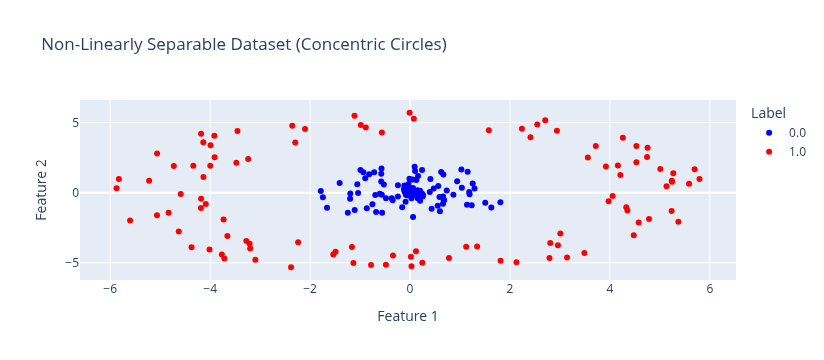

In [7]:
fig = px.scatter(
    x=X_non_linear[:, 0], 
    y=X_non_linear[:, 1], 
    color=y_non_linear.flatten().astype(str),
    title="Non-Linearly Separable Dataset (Concentric Circles)",
    labels={'x': 'Feature 1', 'y': 'Feature 2', 'color': 'Label'},
    color_discrete_map={'0.0': 'blue', '1.0': 'red'}
)

fig.show()

We try training our neuron against this example.

In [8]:
# Convert non-linear data to tensors
X_nl_tensor = torch.from_numpy(X_non_linear).float()
y_nl_tensor = torch.from_numpy(y_non_linear).float()

# Re-initialize the model to reset weights
model_nl = MyNeuron()
criterion = nn.MSELoss()
optimizer = optim.SGD(model_nl.parameters(), lr=0.1)

# Training loop
for epoch in range(1000):
    y_pred = model_nl(X_nl_tensor)
    loss = criterion(y_pred, y_nl_tensor)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

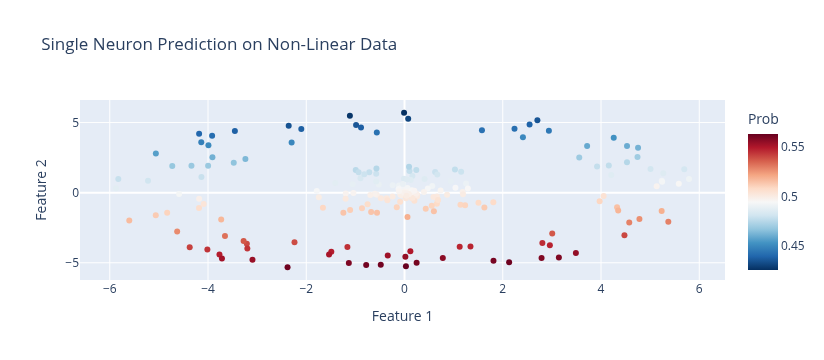

In [9]:
model_nl.eval()
with torch.no_grad():
    predictions_nl = model_nl(X_nl_tensor).numpy().flatten()

fig = px.scatter(
    x=X_non_linear[:, 0], 
    y=X_non_linear[:, 1], 
    color=predictions_nl,
    title="Single Neuron Prediction on Non-Linear Data",
    labels={'x': 'Feature 1', 'y': 'Feature 2', 'color': 'Prob'},
    color_continuous_scale='RdBu_r'
)
fig.show()

That's not good at all! We'll need some feature engineering to make that work. Or... we could learn those features.

To solve this, we must introduce a hidden layer. By using multiple neurons, the first layer can learn to transform the coordinate space into new "features," and the final neuron can then combine those features to form a non-linear boundary.

The following model uses a hidden layer with 8 neurons and a ReLU (Rectified Linear Unit) activation function. The final layer remains a single neuron with a Sigmoid activation to produce a probability.

In [10]:
class MyNeuralNet(nn.Module):
    def __init__(self):
        super(MyNeuralNet, self).__init__()
        # First layer: 2 inputs -> 8 hidden features
        self.hidden = nn.Linear(2, 8)
        # Activation function for hidden layer
        self.relu = nn.ReLU()
        # Second layer: 8 hidden features -> 1 output
        self.output = nn.Linear(8, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.hidden(x)
        x = self.relu(x)
        x = self.output(x)
        x = self.sigmoid(x)
        return x

# Initialize the network
net = MyNeuralNet()

In [11]:
optimizer = optim.SGD(net.parameters(), lr=0.1)
criterion = nn.MSELoss()

# Training loop
for epoch in range(3000):
    y_pred = net(X_nl_tensor)
    loss = criterion(y_pred, y_nl_tensor)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 500 == 0:
        print(f'Epoch [{epoch+1}/3000], Loss: {loss.item():.4f}')

Epoch [500/3000], Loss: 0.0206
Epoch [1000/3000], Loss: 0.0080
Epoch [1500/3000], Loss: 0.0046
Epoch [2000/3000], Loss: 0.0031
Epoch [2500/3000], Loss: 0.0023
Epoch [3000/3000], Loss: 0.0017


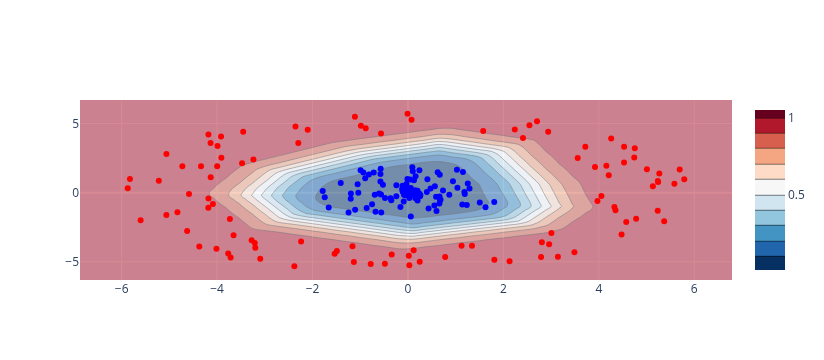

In [12]:
# Create a grid of points
x_min, x_max = X_non_linear[:, 0].min() - 1, X_non_linear[:, 0].max() + 1
y_min, y_max = X_non_linear[:, 1].min() - 1, X_non_linear[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 50), np.linspace(y_min, y_max, 50))
grid_tensor = torch.from_numpy(np.c_[xx.ravel(), yy.ravel()]).float()

# Get predictions over the grid
net.eval()
with torch.no_grad():
    grid_preds = net(grid_tensor).numpy().reshape(xx.shape)

# Plot using Plotly Contour
import plotly.graph_objects as go

fig = go.Figure()
fig.add_trace(go.Contour(x=np.linspace(x_min, x_max, 50), y=np.linspace(y_min, y_max, 50), 
                         z=grid_preds, colorscale='RdBu_r', opacity=0.5))
fig.add_trace(go.Scatter(x=X_non_linear[:, 0], y=X_non_linear[:, 1], 
                         mode='markers', marker=dict(color=y_non_linear.flatten(), colorscale=['blue', 'red'])))
fig.show()

## Another demo, for regression

Below I train a network with one hidden layer of six nodes on a fairly complex, difficult-to-fit function. I encourage you not to pay too much attention to this code at this stage.

The output plot illustrates the predictive line in red, and the features that have been learned by the hidden layer, and are being linearly combined by the output layer, to make that prediction as dotted lines.

Epoch 0: Loss 0.68972
Epoch 500: Loss 0.00837
Epoch 1000: Loss 0.00818
Epoch 1500: Loss 0.00821


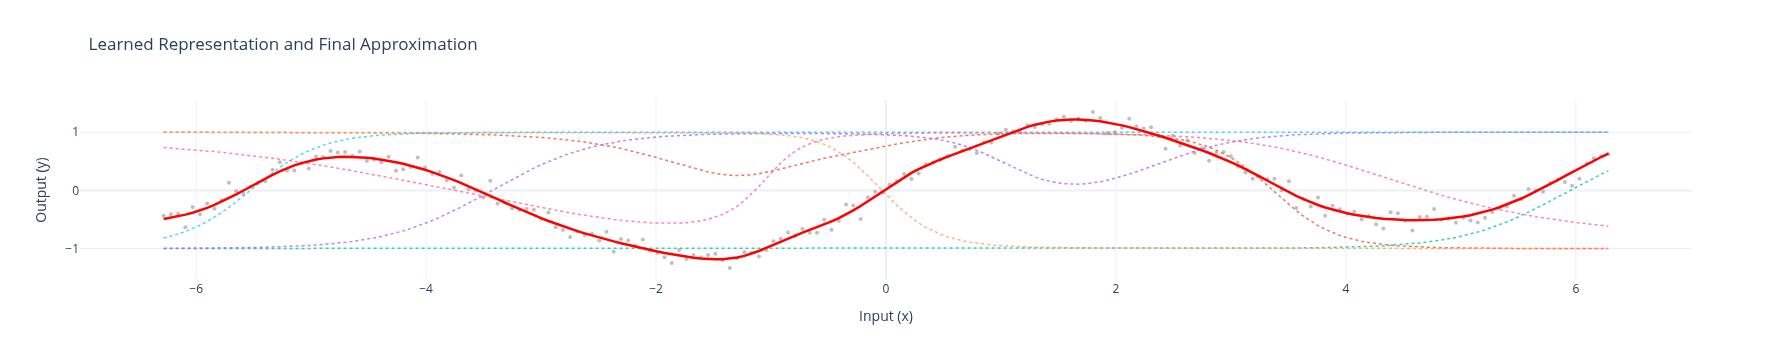

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
import plotly.graph_objects as go
import numpy as np

# 1. Data Generation
def target_function(x):
    return torch.sin(x) + 0.1 * x

torch.manual_seed(42)

x_train = torch.linspace(-2 * np.pi, 2 * np.pi, 200).unsqueeze(1)
y_train = target_function(x_train) + 0.1 * torch.randn_like(x_train)

# 2. Model Definition
class RepresentationLearner(nn.Module):
    def __init__(self, n_features=6):
        super().__init__()
        self.feature_extractor = nn.Sequential(
            nn.Linear(1, 64),
            nn.Tanh(),
            nn.Linear(64, n_features),
            nn.Tanh()
        )
        self.final_layer = nn.Linear(n_features, 1)

    def forward(self, x):
        features = self.feature_extractor(x)
        output = self.final_layer(features)
        return output, features

model = RepresentationLearner(n_features=6)

# 3. Training Loop
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

epochs = 2000
for epoch in range(epochs):
    optimizer.zero_grad()
    outputs, _ = model(x_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()
    
    if epoch % 500 == 0:
        print(f"Epoch {epoch}: Loss {loss.item():.5f}")

# 4. Evaluation and Visualization
model.eval()
with torch.no_grad():
    y_pred, features = model(x_train)

# Convert to numpy
x_np = x_train.flatten().numpy()
y_train_np = y_train.flatten().numpy()
y_pred_np = y_pred.flatten().numpy()
features_np = features.numpy()

# Plotting with Plotly
fig = go.Figure()

# Plot original data (Scatter)
fig.add_trace(go.Scatter(
    x=x_np, y=y_train_np,
    mode='markers',
    marker=dict(color='gray', size=4, opacity=0.5),
    name='Data Targets'
))

# Plot learned basis functions (Dotted lines)
num_features = features_np.shape[1]
for i in range(num_features):
    fig.add_trace(go.Scatter(
        x=x_np, y=features_np[:, i],
        mode='lines',
        line=dict(dash='dot', width=1.5),
        opacity=0.8,
        name=f'Basis Function {i+1}',
        legendgroup="basis",
        showlegend=True if i == 0 else False
    ))

# Plot model prediction (Solid curve)
fig.add_trace(go.Scatter(
    x=x_np, y=y_pred_np,
    mode='lines',
    line=dict(color='red', width=2.5),
    name='Model Prediction'
))

# Layout updates
fig.update_layout(
    title="Learned Representation and Final Approximation",
    xaxis_title="Input (x)",
    yaxis_title="Output (y)",
    template="plotly_white",
    showlegend=False
)

fig.show()

The learned functions are bespoke, and highly effective at fitting this data. And we didn't have to think about them at all!